## **Supervised Machine Learning Model**

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [3]:
# import dataset
df = pd.read_csv("sample.csv")

df = df.drop(columns = ["id"])
# drop unreasonable values in age and employment length
df = df[(df["person_age"] <= 100) & (df["person_emp_length"] <= 100)]

# log transformation
df["log_person_income"] = np.log1p(df["person_income"])

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status,log_person_income
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0,10.463132
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0,10.933125
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0,10.268165
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0,11.156265
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0,11.002117


In [4]:
# preprocessing

# age & age_sq
df["person_age_sq"] = (df["person_age"] - df["person_age"].mean()) ** 2

# person_home_ownership => dummy (reference = OWN)
df = pd.get_dummies(df, columns = ["person_home_ownership"], prefix = "", prefix_sep = "", dtype = int)

# loan_intent => dummy (reference = EDUCATION)
df = pd.get_dummies(df, columns = ["loan_intent"], prefix = "", prefix_sep = "", dtype = int)

# loan_grade => dummy (reference = A)
df = pd.get_dummies(df, columns = ["loan_grade"], prefix = "", prefix_sep = "", dtype = int)

# cb_person_default_on_file
df["cb_person_default_on_file"] = df["cb_person_default_on_file"].map({"N": 0, "Y": 1})

# select features
features = ["log_person_income", "person_age", "person_age_sq", "person_emp_length", "MORTGAGE", "OTHER", "RENT", "MEDICAL", "PERSONAL", "VENTURE", "DEBTCONSOLIDATION", "HOMEIMPROVEMENT", "B", "C", "D", "E", "F", "G", "loan_int_rate", "loan_percent_income", "cb_person_default_on_file", "cb_person_cred_hist_length"]

In [5]:
# VIF

x = df[features]
# add intercept
x_with_constant = sm.add_constant(x)

vif_df = pd.DataFrame()
vif_df["feature"] = x_with_constant.columns
vif_df["VIF"] = [variance_inflation_factor(x_with_constant.values, i) for i in range(x_with_constant.shape[1])]

vif_df = vif_df[vif_df["feature"] != "const"].sort_values(by = "VIF", ascending = False)
print(vif_df)

                       feature        VIF
19               loan_int_rate  10.825715
14                           C   8.587884
15                           D   7.412277
2                   person_age   5.874959
5                     MORTGAGE   5.380176
7                         RENT   5.273373
13                           B   4.932896
22  cb_person_cred_hist_length   4.357509
16                           E   2.920196
3                person_age_sq   2.059953
21   cb_person_default_on_file   1.715702
8                      MEDICAL   1.568268
9                     PERSONAL   1.531891
10                     VENTURE   1.524920
11           DEBTCONSOLIDATION   1.493131
12             HOMEIMPROVEMENT   1.412495
17                           F   1.394598
1            log_person_income   1.335435
20         loan_percent_income   1.162614
4            person_emp_length   1.138997
18                           G   1.115547
6                        OTHER   1.028011


=> During the VIF check, a high multicollinearity was observed between loan_grade and loan_int_rate (VIF > 10). 
This is due to the risk-based pricing, borrowers with worse loan grade generally will be given a higher interest rate. 

### 1. Logistic Regression

In [8]:
# select features
base_features = ["log_person_income", "person_age", "person_age_sq", "person_emp_length", "MORTGAGE", "OTHER", "RENT", "MEDICAL", "PERSONAL", "VENTURE", "DEBTCONSOLIDATION", "HOMEIMPROVEMENT", "loan_percent_income", "cb_person_default_on_file", "cb_person_cred_hist_length"]
features_A = base_features + ["B", "C", "D", "E", "F", "G"]
features_B = base_features + ["loan_int_rate"]

y = df["loan_status"]

In [9]:
# split data into training and test data

def split_and_scale_data(features_list):
    x = df[features_list]
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)
    
    # scaling
    scaler = StandardScaler()
    x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns = features_list, index = x_train.index)
    x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns = features_list, index = x_test.index)
    
    return x_train_scaled, x_test_scaled, y_train, y_test

x_train_A, x_test_A, y_train_A, y_test_A = split_and_scale_data(features_A)
x_train_B, x_test_B, y_train_B, y_test_B = split_and_scale_data(features_B)

In [10]:
# model evaluation results

results = []

def evaluate_model(model, x_test, y_test, model_name):

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    
    print(f"{model_name}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print(f"ROC-AUC Score: {auc:.4f}\n")
    
    return {"Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC-AUC": auc}

In [11]:
# model A: use loan_grade

x_train_A_const = sm.add_constant(x_train_A)
sm_model_A = sm.Logit(y_train_A, x_train_A_const).fit()
print(sm_model_A.summary())

logistic_model_A = LogisticRegression(class_weight = "balanced", max_iter = 1000, random_state = 42)
logistic_model_A.fit(x_train_A, y_train_A)
logistic_A_result = evaluate_model(logistic_model_A, x_test_A, y_test_A, "Logistic Regression (loan_grade)")
results.append(logistic_A_result)

Optimization terminated successfully.
         Current function value: 0.238153
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                46913
Model:                          Logit   Df Residuals:                    46891
Method:                           MLE   Df Model:                           21
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                  0.4181
Time:                        18:27:24   Log-Likelihood:                -11172.
converged:                       True   LL-Null:                       -19199.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -3.0022      0.029   -104.433      0.000      

=> Credit history length (cb_person_cred_hist_length) is highly correlated with age (person_age).

=> Default history (cb_person_default_on_file) is already captured by loan grade (loan_grade).

In [13]:
# model B: use loan_int_rate

x_train_B_const = sm.add_constant(x_train_B)
sm_model_B = sm.Logit(y_train_B, x_train_B_const).fit()
print(sm_model_B.summary())

logistic_model_B = LogisticRegression(class_weight = "balanced", max_iter = 1000, random_state = 42)
logistic_model_B.fit(x_train_B, y_train_B)
logistic_B_result = evaluate_model(logistic_model_B, x_test_B, y_test_B, "Logistic Regression (loan_int_rate)")
results.append(logistic_B_result)

Optimization terminated successfully.
         Current function value: 0.261042
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                46913
Model:                          Logit   Df Residuals:                    46896
Method:                           MLE   Df Model:                           16
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                  0.3621
Time:                        18:27:24   Log-Likelihood:                -12246.
converged:                       True   LL-Null:                       -19199.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -2.9812      0.028   -105.898      0.000      

=> Credit history length (cb_person_cred_hist_length) is highly correlated with age (person_age).

=> Loan grade already summarizes borrower risk information, interest rate may reflect noise from external factors such as market conditions and lender policies. Based on these results, Model A is selected for subsequent modeling and analysis.

In [15]:
# Final Logistic Regression: use loan_grade, remove cb_person_cred_hist_length & cb_person_default_on_file

model_features = ["log_person_income", "person_age", "person_age_sq", "person_emp_length", "MORTGAGE", "OTHER", "RENT", "MEDICAL", "PERSONAL", "VENTURE", "DEBTCONSOLIDATION", "HOMEIMPROVEMENT", "B", "C", "D", "E", "F", "G", "loan_percent_income"]
x_train_scaled, x_test_scaled, y_train, y_test = split_and_scale_data(model_features)

x_train_const = sm.add_constant(x_train_scaled)
sm_model = sm.Logit(y_train, x_train_const).fit()
print(sm_model.summary())

logistic_model = LogisticRegression(class_weight = "balanced", max_iter = 1000, random_state = 42)
logistic_model.fit(x_train_scaled, y_train)
logistic_probs = logistic_model.predict_proba(x_test_scaled)[:, 1]
logistic_result = evaluate_model(logistic_model, x_test_scaled, y_test, "Logistic Regression")
results.append(logistic_result)

Optimization terminated successfully.
         Current function value: 0.238173
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                46913
Model:                          Logit   Df Residuals:                    46893
Method:                           MLE   Df Model:                           19
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                  0.4180
Time:                        18:27:25   Log-Likelihood:                -11173.
converged:                       True   LL-Null:                       -19199.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -3.0016      0.029   -104.443      0.000      -3.058      -2.945
lo

### 2. Random Forest

In [17]:
# no scaling
x = df[model_features]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [18]:
# Hyperparameter Tuning

# define search grid
rf_param_grid = {"n_estimators": [100, 150, 200, 250, 300],
                 "max_depth": [6, 8, 10, 12, 15],
                 "min_samples_split": [2, 5, 10],
                 "max_features": ["sqrt", "log2", 0.5, 0.7]}

rf_base = RandomForestClassifier(class_weight = "balanced", random_state = 42)

# RandomizedSearchCV
rf_random_search = RandomizedSearchCV(estimator = rf_base,
                                      param_distributions = rf_param_grid,
                                      n_iter = 40,
                                      scoring = "roc_auc",
                                      cv = 5,
                                      verbose = 1,
                                      random_state = 42,
                                      n_jobs = -1)
rf_random_search.fit(x_train, y_train)

# best rf model
rf_best_model = rf_random_search.best_estimator_
print(f"Random Forest Best Parameters: {rf_random_search.best_params_}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Random Forest Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'max_features': 0.7, 'max_depth': 15}


In [19]:
rf_model = RandomForestClassifier(n_estimators = 100, max_depth = 15, min_samples_split = 10, max_features = 0.7, class_weight = "balanced", random_state = 42, n_jobs = -1)
rf_model.fit(x_train, y_train)
rf_probs = rf_model.predict_proba(x_test)[:, 1]
rf_result = evaluate_model(rf_model, x_test, y_test, "Random Forest")
results.append(rf_result)

Random Forest
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     10059
           1       0.85      0.75      0.80      1670

    accuracy                           0.95     11729
   macro avg       0.90      0.86      0.88     11729
weighted avg       0.94      0.95      0.94     11729

ROC-AUC Score: 0.9417



### 3. XGBoost Classifier

In [21]:
neg_cases = y_train.value_counts()[0]
pos_cases = y_train.value_counts()[1]
scale_weight = neg_cases / pos_cases

In [22]:
# Hyperparameter Tuning

# define search grid
xgb_param_grid = {"n_estimators": [100, 150, 200, 250, 300],
                  "max_depth": [5, 6, 7, 8],
                  "learning_rate": [0.01, 0.05, 0.1],
                  "subsample": [0.7, 0.8, 0.9],
                  "colsample_bytree": [0.7, 0.8, 0.9],
                  "scale_pos_weight": [scale_weight]}

xgb_base = XGBClassifier(eval_metric = "logloss", random_state = 42)

# RandomizedSearchCV
xgb_random_search = RandomizedSearchCV(estimator = xgb_base,
                                       param_distributions = xgb_param_grid,
                                       n_iter = 40,
                                       scoring = "roc_auc",
                                       cv = 5,
                                       verbose = 1,
                                       random_state = 42,
                                       n_jobs = -1)
xgb_random_search.fit(x_train, y_train)

# best xgb model
xgb_best_model = xgb_random_search.best_estimator_
print(f"Best Parameters: {xgb_random_search.best_params_}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'subsample': 0.9, 'scale_pos_weight': 6.023955681988322, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


In [23]:
xgb_model = XGBClassifier(n_estimators = 300, max_depth = 5, learning_rate = 0.1, subsample = 0.9, colsample_bytree = 0.9, scale_pos_weight = scale_weight, random_state = 42, eval_metric = "logloss")
xgb_model.fit(x_train, y_train)
xgb_probs = xgb_model.predict_proba(x_test)[:, 1]
xgb_result = evaluate_model(xgb_model, x_test, y_test, "XGBoost Classifier")
results.append(xgb_result)

XGBoost Classifier
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     10059
           1       0.72      0.84      0.78      1670

    accuracy                           0.93     11729
   macro avg       0.85      0.89      0.87     11729
weighted avg       0.94      0.93      0.93     11729

ROC-AUC Score: 0.9600



XGBoost Feature Importance:
                Feature  Importance
14                    D    0.321958
15                    E    0.163185
18  loan_percent_income    0.078523
6                  RENT    0.075174
16                    F    0.049979
11      HOMEIMPROVEMENT    0.049838
13                    C    0.035502
9               VENTURE    0.029774
10    DEBTCONSOLIDATION    0.028070
7               MEDICAL    0.027726


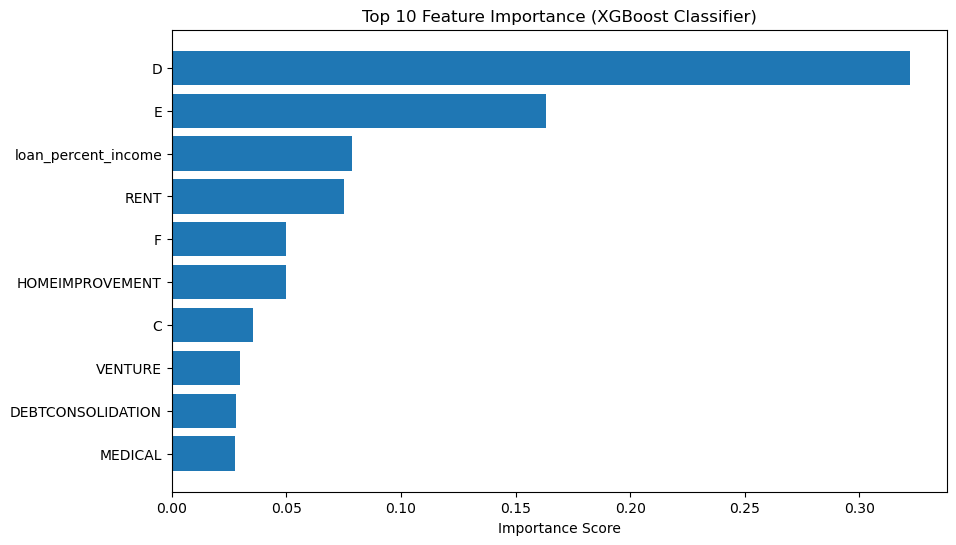

In [24]:
# feature importance

feature_importances = pd.DataFrame({"Feature": x_train.columns, "Importance": xgb_model.feature_importances_}).sort_values(by = "Importance", ascending = False)

print("XGBoost Feature Importance:")
print(feature_importances.head(10))

plt.figure(figsize = (10, 6))
plt.barh(feature_importances["Feature"][:10][::-1], feature_importances["Importance"][:10][::-1])
plt.title("Top 10 Feature Importance (XGBoost Classifier)")
plt.xlabel("Importance Score")
plt.show()

### 4. Model comparison

In [26]:
comparison_df = pd.DataFrame(results).round(4)
comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression (loan_grade),0.8383,0.4624,0.8311,0.5942,0.9043
1,Logistic Regression (loan_int_rate),0.7984,0.3996,0.8281,0.5391,0.8869
2,Logistic Regression,0.8391,0.4637,0.8311,0.5953,0.9043
3,Random Forest,0.9453,0.8512,0.7467,0.7955,0.9417
4,XGBoost Classifier,0.9318,0.7238,0.8425,0.7786,0.9600


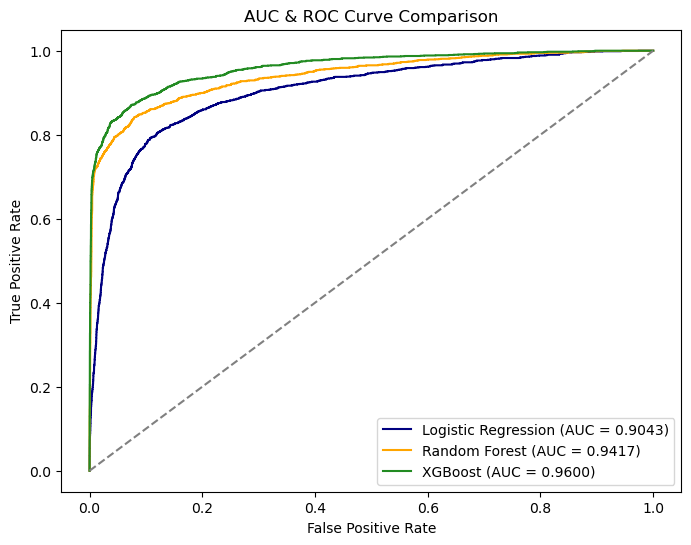

In [27]:
# AUC & ROC Curve

models = {"Logistic Regression": (logistic_probs, "navy"),
          "Random Forest": (rf_probs, "orange"),
          "XGBoost": (xgb_probs, "forestgreen")}

plt.figure(figsize = (8, 6))

for model, (probs, color) in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color = color, label = f"{model} (AUC = {auc_score:.4f})")
    
# random guess line
plt.plot([0,1], [0,1], linestyle = "--", color = "gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC & ROC Curve Comparison")
plt.legend(loc = "lower right")
plt.show()

=> Logistic Regression was used as a baseline model, followed by tree-based models for comparison.

=> Among the tested models, XGBoost performed best overall on ROC-AUC and F1, suggesting that nonlinear interactions among borrower characteristics and loan features are important for predicting loan status.